# Single-Stock Analysis Playbook Template (OpenBB + FinanceToolkit)

This notebook is designed as a decision pipeline: each phase reduces uncertainty about whether a stock is attractive **now**, not just whether the company is good in general.

For readers new to finance, think of this like debugging a production system in layers:
- **Business quality** asks if the company has a durable engine.
- **Fundamentals** asks whether that engine is improving or weakening.
- **Technicals** asks whether timing and market behavior support entry now.
- **Valuation** asks whether the current price is expensive, fair, or cheap versus fundamentals.
- **Risk & relative analysis** asks how this position behaves inside a portfolio.
- **Decision framework** converts evidence into a repeatable action.

**Primary data source:** OpenBB `provider="fmp_cached"`  
**Fallback:** OpenBB `provider="fmp"` if a specific endpoint fails under cached mode.

## Notebook Setup

Before analysis, we make sure the environment is reproducible and data credentials are loaded.

**Why this matters financially:** if your data source, package versions, or credentials differ between runs, your investment conclusions can drift for non-economic reasons. This setup step ensures that later differences in outputs are about the company/market, not tooling noise.

### Initial setup checklist (run once per environment)
1. Open this repository as the workspace root: `I:\masterswork\git\OpenBB`.
2. Use the project Python environment (`.venv_win`) as the notebook kernel.
3. Install editable source packages for local development.
4. Ensure `.env` exists at `I:\masterswork\git\OpenBB\.env` with `FMP_API_KEY` (or `FMP_API`).
5. Verify `seaborn` is installed in the same environment for Phase 6 visuals.

### Run order for each new session
1. Run Cell 3 (imports + credentials setup).
2. Run Cell 5 (configuration inputs).
3. Run Cell 7 (helper functions).
4. Run remaining cells in order from Phase 1 to Phase 7.

### Maintenance rules
- Keep `PRIMARY_PROVIDER = "fmp_cached"` and `FALLBACK_PROVIDER = "fmp"`.
- If provider or schema behavior changes, update helper logic in Cell 7 first.
- Re-run all cells after any package update or kernel restart.

In [47]:
import os
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

warnings.filterwarnings("ignore")

# Editable installs are now expected for OpenBB + FinanceToolkit.
from openbb import obb
import openbb
from financetoolkit import Toolkit

# Environment variables
load_dotenv(r"I:\masterswork\git\OpenBB\.env", override=True)
fmp_api_key = os.getenv("FMP_API_KEY") or os.getenv("FMP_API")

if fmp_api_key:
    obb.user.credentials.fmp_api_key = fmp_api_key
    obb.user.credentials.fmp_cached_api_key = fmp_api_key

print("Setup complete")
print(f"Python time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"OpenBB loaded from: {openbb.__file__}")
print(f"FinanceToolkit loaded from: {Toolkit.__module__}")
print(f"FMP key loaded: {'YES' if bool(fmp_api_key) else 'NO'}")
print("Primary provider = fmp_cached")

Setup complete
Python time: 2026-02-28 17:39:27
OpenBB loaded from: I:\masterswork\git\OpenBB\openbb_platform\core\openbb\__init__.py
FinanceToolkit loaded from: financetoolkit.toolkit_controller
FMP key loaded: YES
Primary provider = fmp_cached


## Configuration Inputs

This cell defines the analysis scope: which company, what benchmark, and what lookback windows.

**Financial reasoning:** timeframe selection changes conclusions. A 1-year window is useful for market behavior and timing, while a 5-year window is better for business trajectory and capital allocation quality. The benchmark sets the opportunity-cost baseline ("was this better than simply owning the market?").

In [32]:
SYMBOL = "CLS"
BENCHMARK = "SPY"

today = pd.Timestamp.today().normalize()
START_DATE_FUNDAMENTALS = (today - pd.DateOffset(years=5)).strftime("%Y-%m-%d")
START_DATE_TECHNICALS = (today - pd.DateOffset(years=1)).strftime("%Y-%m-%d")
END_DATE = today.strftime("%Y-%m-%d")

PRIMARY_PROVIDER = "fmp_cached"
FALLBACK_PROVIDER = "fmp"
RISK_FREE_RATE = 0.02

load_dotenv(r"I:\\masterswork\\git\\OpenBB\\.env")
API_KEY = os.getenv("FMP_API_KEY")

obb.user.preferences.output_type = "dataframe"

print({
    "symbol": SYMBOL,
    "benchmark": BENCHMARK,
    "fundamental_start": START_DATE_FUNDAMENTALS,
    "technical_start": START_DATE_TECHNICALS,
    "end_date": END_DATE,
    "primary_provider": PRIMARY_PROVIDER,
    "fallback_provider": FALLBACK_PROVIDER,
    "api_key_loaded": API_KEY is not None
})

{'symbol': 'CLS', 'benchmark': 'SPY', 'fundamental_start': '2021-02-28', 'technical_start': '2025-02-28', 'end_date': '2026-02-28', 'primary_provider': 'fmp_cached', 'fallback_provider': 'fmp', 'api_key_loaded': True}


## Helper Functions

These utilities standardize data retrieval and extraction so later financial interpretation is stable.

**Financial reasoning:** analysis quality depends on consistent data shape and fallback behavior. If one endpoint fails or schema changes slightly, we still want comparable KPIs rather than a broken or silently biased result. Think of this as building a reliable data contract before computing investment signals.

In [33]:
def to_df(obj):
    if obj is None:
        return pd.DataFrame()
    if hasattr(obj, "to_df"):
        df = obj.to_df()
        if isinstance(df, pd.DataFrame):
            return df
    if isinstance(obj, pd.DataFrame):
        return obj
    return pd.DataFrame()


def call_obb(endpoint, *args, provider_priority=None, **kwargs):
    providers = provider_priority or [PRIMARY_PROVIDER, FALLBACK_PROVIDER]
    errors = []
    for provider in providers:
        try:
            return endpoint(*args, provider=provider, **kwargs), provider
        except Exception as exc:
            errors.append((provider, str(exc)))
    error_text = "; ".join([f"{p}: {e}" for p, e in errors])
    raise RuntimeError(f"All providers failed for {endpoint}: {error_text}")


def first_available_value(df, candidates, default=None):
    if df is None or df.empty:
        return default
    lower_map = {c.lower(): c for c in df.columns}
    for c in candidates:
        key = c.lower()
        if key in lower_map:
            series = df[lower_map[key]].dropna()
            if len(series):
                return series.iloc[0]
    return default


def last_numeric(series_or_df):
    if isinstance(series_or_df, pd.DataFrame):
        numeric = series_or_df.select_dtypes(include=["number"])
        if numeric.empty:
            return np.nan
        vals = numeric.tail(1).values.flatten()
        vals = [v for v in vals if pd.notna(v)]
        return vals[0] if vals else np.nan
    if isinstance(series_or_df, pd.Series):
        ser = pd.to_numeric(series_or_df, errors="coerce").dropna()
        return ser.iloc[-1] if len(ser) else np.nan
    return np.nan

## Phase 1 — Company Profile & Business Quality

This phase answers: **What business are we actually buying?**
- Profile and quote data establish economic context (sector, industry, size, current market pricing).
- Peer data sets the comparison set, because "good" or "expensive" is relative to alternatives.

For non-finance readers: this is equivalent to identifying system boundaries before performance analysis—you need the right peer architecture before judging efficiency.

In [34]:
profile_obj, profile_provider = call_obb(obb.equity.profile, symbol=SYMBOL)
quote_obj, quote_provider = call_obb(obb.equity.price.quote, symbol=SYMBOL)
metrics_obj, metrics_provider = call_obb(obb.equity.fundamental.metrics, symbol=SYMBOL, period="annual", limit=5)

profile_df = to_df(profile_obj)
quote_df = to_df(quote_obj)
metrics_df = to_df(metrics_obj)

peers_obj, peers_provider = call_obb(obb.equity.compare.peers, symbol=SYMBOL)
peers_df = to_df(peers_obj)

print("Providers used:", {
    "profile": profile_provider,
    "quote": quote_provider,
    "metrics": metrics_provider,
    "peers": peers_provider,
})

display(profile_df.head(1))
display(quote_df.head(1))
display(metrics_df.head(5))
display(peers_df.head(10))

Providers used: {'profile': 'fmp_cached', 'quote': 'fmp_cached', 'metrics': 'fmp_cached', 'peers': 'fmp_cached'}


,symbol,name,cik,cusip,isin,stock_exchange,long_description,ceo,company_url,business_phone_no,...,is_fund,image,currency,market_cap,last_price,year_high,year_low,volume_avg,annualized_dividend_amount,beta
0,CLS,Celestica Inc.,0001030894,15101Q207,CA15101Q2071,NYSE,Celestica Inc. provides hardware platform and ...,Robert Andrew Mionis,https://www.celestica.com,14164485800,...,False,https://images.financialmodelingprep.com/symbo...,USD,31937722310,277.63,363.4,58.05,2733596,0.0,1.505


,symbol,name,exchange,last_price,last_timestamp,open,high,low,volume,prev_close,change,change_percent,year_high,year_low,ma50,ma200,market_cap
0,CLS,Celestica Inc.,NYSE,277.63,2026-02-27 21:00:03,276.99,277.99,270.4642,2179150,279.16,-1.53,-0.0054807,363.4,58.05,298.8724,240.12335,31937722310.0


,symbol,period_ending,fiscal_year,fiscal_period,currency,market_cap,enterprise_value,ev_to_sales,ev_to_operating_cash_flow,ev_to_free_cash_flow,...,average_inventory,days_of_sales_outstanding,days_of_payables_outstanding,days_of_inventory_outstanding,operating_cycle,cash_conversion_cycle,free_cash_flow_to_equity,free_cash_flow_to_firm,tangible_asset_value,net_current_asset_value
0,CLS,2026-02-28,2026,TTM,USD,31937722310,32118293099,2.5877492104812387,48.5214554576152,69.89270842301597,...,2115359084,77.4395418956581,61.96555118252832,72.65453407725008,150.09407597290817,88.12852479037986,278966325.0,765361341.9905047,1614057303,675169053


,symbol,name,price,market_cap
0,SNDK,Sandisk Corporation,635.36,93758327325
1,KEYS,"Keysight Technologies, Inc.",307.33,52799294000
2,GRMN,Garmin Ltd.,252.83,48628009001
3,UI,Ubiquiti Inc.,766.99,46418843790
4,NOK,Nokia Oyj,7.72,41694886240
5,FICO,Fair Isaac Corporation,1409.36,33433026774
6,TDY,Teledyne Technologies Incorporated,681.1,31978318608
7,CTSH,Cognizant Technology Solutions Corporation,64.43,31096911869
8,JBL,Jabil Inc.,264.99,28307015905
9,FLEX,Flex Ltd.,63.02,23304187857


### Phase 1 Synthesis: What to infer from raw profile outputs

This step compresses profile, quote, and peer outputs into a compact business snapshot.

**Financial reasoning:** before deep modeling, we need quick orientation: market cap sets size/risk regime, sector/industry define economic drivers, and peer count indicates breadth of comparable alternatives. This summary is a sanity check that the company is being analyzed in the correct competitive context.

In [35]:
sector = first_available_value(profile_df, ["sector", "sector_name"], default="Unknown")
industry = first_available_value(profile_df, ["industry", "industry_name"], default="Unknown")
market_cap = first_available_value(quote_df, ["market_cap", "marketcap"], default=np.nan)

phase1_summary = pd.DataFrame([
    {
        "symbol": SYMBOL,
        "sector": sector,
        "industry": industry,
        "market_cap": market_cap,
        "peer_count": len(peers_df)
    }
])
display(phase1_summary)

,symbol,sector,industry,market_cap,peer_count
0,CLS,Technology,Unknown,31937722310.0,10


## Phase 2 — 5-Year Fundamental Analysis

This phase measures whether core economics are improving over time.

**Financial reasoning:** long-run compounding comes from growth quality, profitability, and balance-sheet resilience—not just recent price movement. We use multi-year statements to reduce quarter-to-quarter noise and focus on trend direction.

In [36]:
income_obj, income_provider = call_obb(obb.equity.fundamental.income, symbol=SYMBOL, period="annual", limit=5)
balance_obj, balance_provider = call_obb(obb.equity.fundamental.balance, symbol=SYMBOL, period="annual", limit=5)
cash_obj, cash_provider = call_obb(obb.equity.fundamental.cash, symbol=SYMBOL, period="annual", limit=5)
ratios_obj, ratios_provider = call_obb(obb.equity.fundamental.ratios, symbol=SYMBOL, period="annual", limit=5)

income_df = to_df(income_obj)
balance_df = to_df(balance_obj)
cash_df = to_df(cash_obj)
ratios_df = to_df(ratios_obj)

print("Providers used:", {
    "income": income_provider,
    "balance": balance_provider,
    "cash": cash_provider,
    "ratios": ratios_provider,
})

display(income_df.head())
display(balance_df.head())
display(cash_df.head())
display(ratios_df.head())

Providers used: {'income': 'fmp_cached', 'balance': 'fmp_cached', 'cash': 'fmp_cached', 'ratios': 'fmp_cached'}


,period_ending,fiscal_period,fiscal_year,filing_date,accepted_date,cik,symbol,reported_currency,revenue,cost_of_revenue,...,total_pre_tax_income,income_tax_expense,other_adjustments_to_net_income,net_income_deductions,consolidated_net_income,bottom_line_net_income,basic_earnings_per_share,diluted_earnings_per_share,weighted_average_basic_shares_outstanding,weighted_average_diluted_shares_outstanding
0,2025-12-31,FY,2025,2026-02-27,2026-02-27 16:30:28,0001030894,CLS,USD,12607809317,11133952551,...,1000411440,153338083,0,0,847073356,847073356,7.35,7.29,115300000,116200000
1,2024-12-31,FY,2024,2025-03-03,2025-03-03 08:17:29,0001030894,CLS,USD,9646000000,8612300000,...,532200000,104200000,0,0,428000000,428000000,3.62,3.61,118100000,118700000
2,2023-12-31,FY,2023,2024-03-11,2024-03-11 10:42:39,0001030894,CLS,USD,7961000000,7206900000,...,306000000,61600000,0,0,244400000,244400000,2.04,2.03,120100000,120300000
3,2022-12-31,FY,2022,2023-03-13,2023-03-13 10:16:07,0001030894,CLS,USD,7250000000,6600300000,...,239100000,59000000,0,0,180100000,180100000,1.18,1.18,123500000,123600000
4,2021-12-31,FY,2021,2022-03-14,2022-03-14 10:21:58,0001030894,CLS,USD,5634700000,5147700000,...,136000000,32100000,0,0,103900000,103900000,0.82,0.82,126700000,126700000


,period_ending,fiscal_period,fiscal_year,filing_date,accepted_date,cik,symbol,reported_currency,cash_and_cash_equivalents,short_term_investments,...,additional_paid_in_capital,accumulated_other_comprehensive_income,other_total_shareholders_equity,total_common_equity,total_equity_non_controlling_interests,minority_interest,total_liabilities_and_total_equity,total_investments,total_debt,net_debt
0,2025-12-31,FY,2025,2026-02-27,2026-02-27 16:30:28,0001030894,CLS,USD,594516097,0,...,0,0,2212266666,2212266666,2212266666,0,7199973239,0,775086886,180570789
1,2024-12-31,FY,2024,2025-03-03,2025-03-03 08:17:29,0001030894,CLS,USD,423300000,0,...,797500000,-17600000,0,1896000000,1896000000,0,5988200000,9700000,796700000,373400000
2,2023-12-31,FY,2023,2024-03-11,2024-03-11 10:42:39,0001030894,CLS,USD,370400000,0,...,1030599999,-199999,0,1771000000,1771000000,0,5890500000,0,783800000,413400000
3,2022-12-31,FY,2022,2023-03-13,2023-03-13 10:16:07,0001030894,CLS,USD,374500000,0,...,1063599999,-5700000,0,1677700000,1677700000,0,5628000000,0,786100000,411600000
4,2021-12-31,FY,2021,2022-03-14,2022-03-14 10:21:58,0001030894,CLS,USD,394000000,0,...,1029800000,-26800000,0,1463000000,1463000000,0,4666900000,0,801800000,407800000


,period_ending,fiscal_period,fiscal_year,filing_date,accepted_date,cik,symbol,reported_currency,net_income,depreciation_and_amortization,...,net_cash_from_financing_activities,effect_of_exchange_rate_changes_on_cash,net_change_in_cash_and_equivalents,cash_at_beginning_of_period,cash_at_end_of_period,operating_cash_flow,capital_expenditure,income_taxes_paid,interest_paid,free_cash_flow
0,2025-12-31,FY,2025,2026-02-27,2026-02-27 16:30:28,0001030894,CLS,USD,832500000,175700000,...,-288462818,-3848319,171467885,423300000,595600000,671044899,-204722113,0,0,466322786
1,2024-12-31,FY,2024,2025-03-03,2025-03-03 08:17:29,0001030894,CLS,USD,428000000,151900000,...,-208500000,0,52900000,370400000,423300000,473900000,-170900000,106300000,52900000,303000000
2,2023-12-31,FY,2023,2024-03-11,2024-03-11 10:42:39,0001030894,CLS,USD,244400000,130800000,...,-207900000,0,-4100000,374500000,370400000,326200000,-125100000,78400000,68800000,201100000
3,2022-12-31,FY,2022,2023-03-13,2023-03-13 10:16:07,0001030894,CLS,USD,180100000,115900000,...,-121700000,0,-19500000,394000000,374500000,211100000,-109000000,65100000,52900000,102100000
4,2021-12-31,FY,2021,2022-03-14,2022-03-14 10:21:58,0001030894,CLS,USD,103900000,126300000,...,67700000,0,-69800000,463800000,394000000,226800000,-52200000,0,0,174600000


,symbol,period_ending,fiscal_period,fiscal_year,currency,gross_profit_margin,ebit_margin,ebitda_margin,operating_profit_margin,pretax_profit_margin,...,shareholders_equity_per_share,operating_cash_flow_per_share,capex_per_share,free_cash_flow_per_share,net_income_per_ebt,ebt_per_ebit,price_to_fair_value,debt_to_market_cap,effective_tax_rate,enterprise_value_multiple
0,CLS,2026-02-28,TTM,2026,USD,0.1159921593284129,0.08355332920594404,0.09773863020604326,0.07570677275474683,0.07931121112842152,...,19.23710144347826,5.756000156521739,1.7600252956521738,3.995974852173913,0.8468670446561534,1.0476105141260124,14.43200789972035,0.024268696354633686,0.15313295432798368,26.476217285079528


### KPI Derivation Logic (OpenBB-first)

This step transforms statement-level and ratio-level data into interpretable business-health KPIs.

**Financial reasoning:** investors care about directional signals (growth, margins, leverage, liquidity) more than raw line items. By mapping multiple field variants and computing fallbacks, we preserve economic meaning even when provider schemas differ.

In [37]:
# OpenBB-first fundamental KPI extraction (FinanceToolkit-style output table)

def latest_col_value(df, candidates):
    if df is None or df.empty:
        return np.nan
    lower_map = {str(c).lower(): c for c in df.columns}
    for cand in candidates:
        col = lower_map.get(cand.lower())
        if col is not None:
            series = pd.to_numeric(df[col], errors="coerce").dropna()
            if not series.empty:
                return float(series.iloc[0])
    return np.nan

def growth_from_two_rows(df, candidates):
    if df is None or df.empty or len(df) < 2:
        return np.nan
    now = latest_col_value(df.iloc[[0]], candidates)
    prev = latest_col_value(df.iloc[[1]], candidates)
    if pd.notna(now) and pd.notna(prev) and prev != 0:
        return (now / prev) - 1
    return np.nan

income_sorted = income_df.copy()
if "period_ending" in income_sorted.columns:
    income_sorted["period_ending"] = pd.to_datetime(income_sorted["period_ending"], errors="coerce")
    income_sorted = income_sorted.sort_values("period_ending", ascending=False).reset_index(drop=True)

cash_sorted = cash_df.copy()
if "period_ending" in cash_sorted.columns:
    cash_sorted["period_ending"] = pd.to_datetime(cash_sorted["period_ending"], errors="coerce")
    cash_sorted = cash_sorted.sort_values("period_ending", ascending=False).reset_index(drop=True)

balance_sorted = balance_df.copy()
if "period_ending" in balance_sorted.columns:
    balance_sorted["period_ending"] = pd.to_datetime(balance_sorted["period_ending"], errors="coerce")
    balance_sorted = balance_sorted.sort_values("period_ending", ascending=False).reset_index(drop=True)

# Primary source: OpenBB ratios endpoint
fundamental_kpis = {
    "Revenue Growth (last)": growth_from_two_rows(income_sorted, ["revenue"]),
    "EPS Growth (last)": growth_from_two_rows(income_sorted, ["basic_earnings_per_share", "eps", "eps_diluted", "diluted_earnings_per_share"]),
    "FCF Growth (last)": growth_from_two_rows(cash_sorted, ["free_cash_flow"]),
    "Gross Margin (last)": latest_col_value(ratios_df, ["gross_profit_margin", "gross_margin"]),
    "Operating Margin (last)": latest_col_value(ratios_df, ["operating_profit_margin", "operating_margin"]),
    "Net Margin (last)": latest_col_value(ratios_df, ["net_profit_margin", "net_margin"]),
    "ROIC (last)": latest_col_value(ratios_df, ["return_on_invested_capital", "roic"]),
    "Current Ratio (last)": latest_col_value(ratios_df, ["current_ratio"]),
    "Debt/Equity (last)": latest_col_value(ratios_df, ["debt_to_equity", "debt_to_equity_ratio"]),
}

# Secondary fallbacks from statements if ratio fields are missing
revenue_now = latest_col_value(income_sorted.iloc[[0]] if len(income_sorted) else pd.DataFrame(), ["revenue"])
gross_now = latest_col_value(income_sorted.iloc[[0]] if len(income_sorted) else pd.DataFrame(), ["gross_profit"])
operating_now = latest_col_value(income_sorted.iloc[[0]] if len(income_sorted) else pd.DataFrame(), ["operating_income"])
net_now = latest_col_value(income_sorted.iloc[[0]] if len(income_sorted) else pd.DataFrame(), ["net_income", "net_income_deductions"])

if pd.isna(fundamental_kpis["Gross Margin (last)"]) and pd.notna(gross_now) and pd.notna(revenue_now) and revenue_now != 0:
    fundamental_kpis["Gross Margin (last)"] = gross_now / revenue_now
if pd.isna(fundamental_kpis["Operating Margin (last)"]) and pd.notna(operating_now) and pd.notna(revenue_now) and revenue_now != 0:
    fundamental_kpis["Operating Margin (last)"] = operating_now / revenue_now
if pd.isna(fundamental_kpis["Net Margin (last)"]) and pd.notna(net_now) and pd.notna(revenue_now) and revenue_now != 0:
    fundamental_kpis["Net Margin (last)"] = net_now / revenue_now

debt_now = latest_col_value(balance_sorted.iloc[[0]] if len(balance_sorted) else pd.DataFrame(), ["total_debt"])
equity_now = latest_col_value(balance_sorted.iloc[[0]] if len(balance_sorted) else pd.DataFrame(), ["total_equity", "total_common_equity"])
if pd.isna(fundamental_kpis["Debt/Equity (last)"]) and pd.notna(debt_now) and pd.notna(equity_now) and equity_now != 0:
    fundamental_kpis["Debt/Equity (last)"] = debt_now / equity_now

fundamental_kpi_df = pd.DataFrame.from_dict(fundamental_kpis, orient="index", columns=["value"])
display(fundamental_kpi_df)

,value
Revenue Growth (last),0.30705052011196354
EPS Growth (last),1.0303867403314917
FCF Growth (last),0.5390190957095709
Gross Margin (last),0.1159921593284129
Operating Margin (last),0.07570677275474683
Net Margin (last),0.06716605097642654
ROIC (last),NaN
Current Ratio (last),1.4400446746812678
Debt/Equity (last),0.3503587058071235


## Phase 3 — Technical Analysis & Timing

Fundamentals can tell you **what** to own; technicals help decide **when** to own it.

**Financial reasoning:** market participants react in waves. Momentum, trend strength, volatility, and volume often signal whether upside/downside pressure is building. We use these indicators as timing context, not as a standalone thesis.

Technical source provider: fmp_cached | rows: 251


,RSI(14),ADX(14),ATR,OBV
0,34.61617616793579,11.809796860808465,17.547857142857143,117735439.0


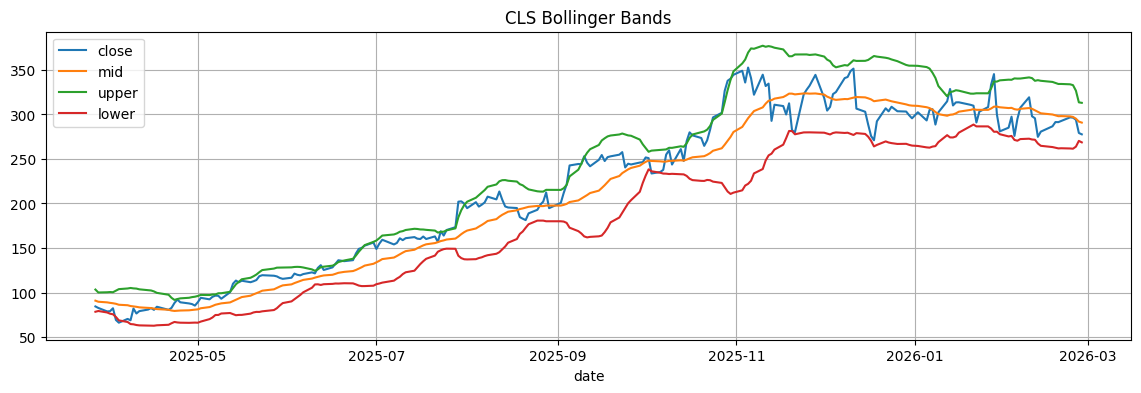

In [38]:
# OpenBB-first technical analysis

symbol_hist_obj, symbol_hist_provider = call_obb(
    obb.equity.price.historical,
    symbol=SYMBOL,
    start_date=START_DATE_TECHNICALS,
    end_date=END_DATE,
    interval="1d",
)
symbol_hist_df = to_df(symbol_hist_obj)
print(f"Technical source provider: {symbol_hist_provider} | rows: {len(symbol_hist_df)}")

if {"date", "symbol", "close"}.issubset(set(symbol_hist_df.columns)):
    _tmp = symbol_hist_df[symbol_hist_df["symbol"].astype(str).str.upper() == SYMBOL.upper()].copy()
else:
    _tmp = symbol_hist_df.copy()

if "date" in _tmp.columns:
    _tmp["date"] = pd.to_datetime(_tmp["date"], errors="coerce")
    _tmp = _tmp.sort_values("date")
    _tmp = _tmp.set_index("date")

close_series = pd.to_numeric(_tmp.get("close", pd.Series(dtype=float)), errors="coerce").dropna()
high_series = pd.to_numeric(_tmp.get("high", pd.Series(index=close_series.index, dtype=float)), errors="coerce")
low_series = pd.to_numeric(_tmp.get("low", pd.Series(index=close_series.index, dtype=float)), errors="coerce")
volume_series = pd.to_numeric(_tmp.get("volume", pd.Series(index=close_series.index, dtype=float)), errors="coerce")

delta = close_series.diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = (-delta.clip(upper=0)).rolling(14).mean()
rs = gain / loss.replace(0, np.nan)
rsi_series = 100 - (100 / (1 + rs))

ema12 = close_series.ewm(span=12, adjust=False).mean()
ema26 = close_series.ewm(span=26, adjust=False).mean()
macd_line = ema12 - ema26
macd_signal = macd_line.ewm(span=9, adjust=False).mean()

prev_close = close_series.shift(1)
tr = pd.concat([
    (high_series - low_series).abs(),
    (high_series - prev_close).abs(),
    (low_series - prev_close).abs(),
], axis=1).max(axis=1)
atr_series = tr.rolling(14).mean()

direction = np.sign(close_series.diff()).fillna(0)
obv_series = (direction * volume_series.fillna(0)).cumsum()

up_move = high_series.diff()
down_move = -low_series.diff()
plus_dm = np.where((up_move > down_move) & (up_move > 0), up_move, 0.0)
minus_dm = np.where((down_move > up_move) & (down_move > 0), down_move, 0.0)
plus_di = 100 * pd.Series(plus_dm, index=close_series.index).rolling(14).sum() / tr.rolling(14).sum()
minus_di = 100 * pd.Series(minus_dm, index=close_series.index).rolling(14).sum() / tr.rolling(14).sum()
dx = ((plus_di - minus_di).abs() / (plus_di + minus_di).replace(0, np.nan)) * 100
adx_series = dx.rolling(14).mean()

bb_mid = close_series.rolling(20).mean()
bb_std = close_series.rolling(20).std()
bb_upper = bb_mid + (2 * bb_std)
bb_lower = bb_mid - (2 * bb_std)

technical_kpis = pd.DataFrame({
    "RSI(14)": [last_numeric(rsi_series)],
    "ADX(14)": [last_numeric(adx_series)],
    "ATR": [last_numeric(atr_series)],
    "OBV": [last_numeric(obv_series)],
})
display(technical_kpis)

bb_plot_df = pd.DataFrame({"close": close_series, "mid": bb_mid, "upper": bb_upper, "lower": bb_lower}).dropna()
if not bb_plot_df.empty:
    bb_plot_df[["close", "mid", "upper", "lower"]].plot(figsize=(14, 4), title=f"{SYMBOL} Bollinger Bands", grid=True)
    plt.show()

## Phase 4 — Valuation & Fair Value

A strong company can still be a poor investment if bought at the wrong price.

**Financial reasoning:** valuation ratios translate current market price into "how much are we paying per unit of earnings/cash flow/sales." This phase tests whether expected business quality is already priced in or if there is potential mispricing.

In [39]:
# OpenBB-first valuation snapshot

def safe_ratio_value(candidates):
    return latest_col_value(ratios_df, candidates)

def safe_df_value(df, candidates):
    return latest_col_value(df, candidates)

price_now = safe_df_value(quote_df, ["last_price", "price"])
eps_now = safe_df_value(income_df, ["basic_earnings_per_share", "eps", "eps_diluted", "diluted_earnings_per_share"])

pe = safe_ratio_value(["price_earnings_ratio", "pe_ratio", "pe"])
if pd.isna(pe) and pd.notna(price_now) and pd.notna(eps_now) and eps_now != 0:
    pe = price_now / eps_now

ev_ebitda = safe_ratio_value(["enterprise_value_multiple", "ev_to_ebitda"])
p_fcf = safe_ratio_value(["price_to_free_cash_flow", "price_to_free_cash_flow_ratio", "p_fcf"])
p_s = safe_ratio_value(["price_to_sales", "price_to_sales_ratio", "ps_ratio"])

earnings_yield = safe_ratio_value(["earnings_yield"])
if pd.isna(earnings_yield) and pd.notna(pe) and pe != 0:
    earnings_yield = 1 / pe

valuation = {
    "Price (last)": price_now,
    "EPS (last)": eps_now,
    "P/E (last)": pe,
    "EV/EBITDA (last)": ev_ebitda,
    "P/FCF (last)": p_fcf,
    "P/S (last)": p_s,
    "Earnings Yield (last)": earnings_yield,
    "WACC (last)": safe_ratio_value(["weighted_average_cost_of_capital", "wacc"]),
    "Piotroski (last)": safe_ratio_value(["piotroski_score"]),
    "Altman Z (last)": safe_ratio_value(["altman_z_score", "altman_z"]),
}

valuation_df = pd.DataFrame.from_dict(valuation, orient="index", columns=["value"])
display(valuation_df)
print("Intrinsic valuation skipped: OpenBB-first mode (no FinanceToolkit dependency)")

,value
Price (last),277.63
EPS (last),7.35
P/E (last),37.77278911564626
EV/EBITDA (last),26.476217285079528
P/FCF (last),69.49976781853273
P/S (last),2.573200743810534
Earnings Yield (last),0.02647408421280121
WACC (last),NaN
Piotroski (last),NaN
Altman Z (last),NaN


Intrinsic valuation skipped: OpenBB-first mode (no FinanceToolkit dependency)


## Phase 5 — Risk & Portfolio Context

This phase asks: **even if expected return is good, is the ride acceptable?**

**Financial reasoning:** risk is not only volatility. We evaluate downside behavior (drawdowns, tail loss) and market sensitivity (beta/alpha) to understand how this position could affect portfolio stability under stress.

In [40]:
# OpenBB-first risk metrics

benchmark_hist_obj, benchmark_hist_provider = call_obb(
    obb.equity.price.historical,
    symbol=BENCHMARK,
    start_date=START_DATE_TECHNICALS,
    end_date=END_DATE,
    interval="1d",
)
benchmark_hist_df = to_df(benchmark_hist_obj)
print(f"Risk benchmark provider: {benchmark_hist_provider} | rows: {len(benchmark_hist_df)}")

def extract_close_series(df, symbol):
    if df is None or df.empty:
        return pd.Series(dtype=float)
    temp = df.copy()
    if {"date", "symbol", "close"}.issubset(set(temp.columns)):
        temp = temp[temp["symbol"].astype(str).str.upper() == symbol.upper()].copy()
    if "date" in temp.columns:
        temp["date"] = pd.to_datetime(temp["date"], errors="coerce")
        temp = temp.sort_values("date").set_index("date")
    return pd.to_numeric(temp.get("close", pd.Series(dtype=float)), errors="coerce").dropna()

symbol_close = extract_close_series(symbol_hist_df, SYMBOL)
benchmark_close = extract_close_series(benchmark_hist_df, BENCHMARK)

returns_df = pd.concat([symbol_close.rename("symbol"), benchmark_close.rename("benchmark")], axis=1).dropna()
asset_returns = returns_df["symbol"].pct_change().dropna()
bench_returns = returns_df["benchmark"].pct_change().dropna()

if asset_returns.empty or bench_returns.empty:
    risk_kpis = {
        "Sharpe": np.nan,
        "Sortino": np.nan,
        "Jensen Alpha": np.nan,
        "Beta": np.nan,
        "VaR": np.nan,
        "CVaR": np.nan,
        "Max Drawdown": np.nan,
        "Ulcer Index": np.nan,
    }
else:
    annual_ret = asset_returns.mean() * 252
    annual_vol = asset_returns.std() * np.sqrt(252)
    downside = asset_returns[asset_returns < 0]
    downside_vol = downside.std() * np.sqrt(252) if not downside.empty else np.nan
    sharpe = (annual_ret - RISK_FREE_RATE) / annual_vol if annual_vol and annual_vol > 0 else np.nan
    sortino = (annual_ret - RISK_FREE_RATE) / downside_vol if pd.notna(downside_vol) and downside_vol > 0 else np.nan

    cov = asset_returns.cov(bench_returns)
    var_bench = bench_returns.var()
    beta = cov / var_bench if pd.notna(var_bench) and var_bench > 0 else np.nan
    jensen_alpha = annual_ret - (RISK_FREE_RATE + beta * ((bench_returns.mean() * 252) - RISK_FREE_RATE)) if pd.notna(beta) else np.nan

    var_95 = asset_returns.quantile(0.05)
    cvar_95 = asset_returns[asset_returns <= var_95].mean()

    equity_curve = (1 + asset_returns).cumprod()
    drawdown = equity_curve / equity_curve.cummax() - 1
    max_drawdown = drawdown.min()
    ulcer_index = np.sqrt((drawdown.pow(2)).mean())

    risk_kpis = {
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Jensen Alpha": jensen_alpha,
        "Beta": beta,
        "VaR": var_95,
        "CVaR": cvar_95,
        "Max Drawdown": max_drawdown,
        "Ulcer Index": ulcer_index,
    }

risk_kpi_df = pd.DataFrame.from_dict(risk_kpis, orient="index", columns=["value"])
display(risk_kpi_df)

Risk benchmark provider: fmp_cached | rows: 251


,value
Sharpe,1.6489940915812753
Sortino,2.3122912980886596
Jensen Alpha,0.9050961696400719
Beta,2.1486673553055295
VaR,-0.06977734009514888
CVaR,-0.10386234199095484
Max Drawdown,-0.33836767353470687
Ulcer Index,0.10627548565906521


## Phase 6 — Market Segment ETF + Peer Relative Analysis

Single-stock conclusions should be checked against realistic alternatives.

**Financial reasoning:** capital is always allocated at the margin. If peers or sector ETFs offer better risk-adjusted returns, the stock may still be inferior despite positive absolute performance. This phase compares the candidate inside its competitive set.

In [41]:
SECTOR_ETF_MAP = {
    "Technology": ["XLK", "VGT"],
    "Financial Services": ["XLF", "VFH"],
    "Financial": ["XLF", "VFH"],
    "Healthcare": ["XLV", "VHT"],
    "Health Care": ["XLV", "VHT"],
    "Industrials": ["XLI", "VIS"],
    "Consumer Cyclical": ["XLY", "VCR"],
    "Consumer Defensive": ["XLP", "VDC"],
    "Energy": ["XLE", "VDE"],
    "Basic Materials": ["XLB", "VAW"],
    "Utilities": ["XLU", "VPU"],
    "Real Estate": ["XLRE", "VNQ"],
    "Communication Services": ["XLC", "VOX"],
}

peer_candidates = []
if not peers_df.empty:
    peer_cols = [c for c in peers_df.columns if c.lower() in ["symbol", "peer", "ticker"]]
    if peer_cols:
        peer_candidates = peers_df[peer_cols[0]].dropna().astype(str).tolist()

peer_candidates = [p for p in peer_candidates if p.upper() != SYMBOL.upper()]
peer_candidates = list(dict.fromkeys(peer_candidates))[:10]

sector_etfs = SECTOR_ETF_MAP.get(str(sector), ["SPY"])
universe = list(dict.fromkeys([SYMBOL] + peer_candidates + sector_etfs + [BENCHMARK]))

print("Sector:", sector)
print("Peer candidates:", peer_candidates)
print("ETF benchmark basket:", sector_etfs)
print("Universe:", universe)

Sector: Technology
Peer candidates: ['SNDK', 'KEYS', 'GRMN', 'UI', 'NOK', 'FICO', 'TDY', 'CTSH', 'JBL', 'FLEX']
ETF benchmark basket: ['XLK', 'VGT']
Universe: ['CLS', 'SNDK', 'KEYS', 'GRMN', 'UI', 'NOK', 'FICO', 'TDY', 'CTSH', 'JBL', 'FLEX', 'XLK', 'VGT', 'SPY']


### Pulling Comparable Price History

This step gathers time-aligned historical prices for the stock, peers, sector ETFs, and benchmark.

**Financial reasoning:** relative performance metrics are only meaningful when assets are observed on a comparable timeline. We build a common history first so return/risk comparisons are apples-to-apples.

In [42]:
hist_obj, hist_provider = call_obb(
    obb.equity.price.historical,
    symbol=",".join(universe),
    start_date=START_DATE_TECHNICALS,
    end_date=END_DATE,
    interval="1d",
)
hist_df = to_df(hist_obj)
print("Historical data provider:", hist_provider, "rows:", len(hist_df))
display(hist_df.head())

Historical data provider: fmp_cached rows: 3514


,open,high,low,close,volume,vwap,change,change_percent,symbol,dividend
date,,,,,,,,,,
2025-02-28,103.31,108.57,101.18,107.05,6518831,105.0275,3.74,0.0362,CLS,NaN
2025-02-28,84.24,84.45,82.34,83.33,5554414,83.59,-0.91,-0.0108,CTSH,NaN
2025-02-28,1832.9,1886.35,1832.9,1886.35,248509,1859.625,53.45,0.0292,FICO,NaN
2025-02-28,37.37,37.99,37.07,37.89,7065800,37.58,0.52,0.0139,FLEX,NaN
2025-02-28,225.06,229.49,224.23,228.93,1207449,226.9275,3.87,0.0172,GRMN,NaN


### Relative Metrics Computation

This step converts close prices into comparable return/risk metrics across the universe.

**Financial reasoning:**
- Annual return shows reward magnitude.
- Volatility shows uncertainty of that reward path.
- Sharpe approximates reward per unit of total risk.
- VaR/CVaR focus on adverse tail behavior.
- Max drawdown captures worst peak-to-trough pain investors would have experienced.

In [45]:
# Build close matrix robustly
temp_hist = hist_df.copy()

# Normalize date to a column when it is the index
if "date" not in temp_hist.columns:
    if str(temp_hist.index.name).lower() == "date" or isinstance(temp_hist.index, pd.DatetimeIndex):
        temp_hist = temp_hist.reset_index().rename(columns={temp_hist.reset_index().columns[0]: "date"})

# Preferred path: long format with symbol + close
if {"date", "symbol", "close"}.issubset(set(temp_hist.columns)):
    temp_hist["date"] = pd.to_datetime(temp_hist["date"], errors="coerce")
    temp_hist["close"] = pd.to_numeric(temp_hist["close"], errors="coerce")
    temp_hist["symbol"] = temp_hist["symbol"].astype(str).str.upper()
    close = (
        temp_hist.dropna(subset=["date", "symbol", "close"])
        .pivot_table(index="date", columns="symbol", values="close", aggfunc="last")
        .sort_index()
    )
else:
    close = temp_hist.copy()
    if "date" in close.columns:
        close["date"] = pd.to_datetime(close["date"], errors="coerce")
        close = close.set_index("date").sort_index()
    # If a close column exists without symbol split, use it as a single-asset series
    if "close" in close.columns:
        close = close[["close"]].rename(columns={"close": SYMBOL.upper()})
    else:
        # Fallback to numeric columns only
        close = close.apply(pd.to_numeric, errors="coerce")

close = close.dropna(axis=1, how="all").dropna(how="all")

if close.empty or close.shape[1] == 0:
    relative_table = pd.DataFrame(columns=[
        "Annual Return", "Volatility", "Sharpe", "VaR 95%", "CVaR 95%", "Max Drawdown"
    ])
else:
    returns = close.pct_change().dropna(how="all")

    annual_ret = returns.mean() * 252
    annual_vol = returns.std() * np.sqrt(252)
    sharpe = (annual_ret - RISK_FREE_RATE) / annual_vol.replace(0, np.nan)
    var_95 = returns.quantile(0.05)
    cvar_95 = returns.where(returns.le(var_95), np.nan).mean()

    drawdown = (1 + returns).cumprod() / (1 + returns).cumprod().cummax() - 1
    max_drawdown = drawdown.min()

    relative_table = pd.DataFrame({
        "Annual Return": annual_ret,
        "Volatility": annual_vol,
        "Sharpe": sharpe,
        "VaR 95%": var_95,
        "CVaR 95%": cvar_95,
        "Max Drawdown": max_drawdown,
    }).sort_values("Sharpe", ascending=False)

display(relative_table)

,Annual Return,Volatility,Sharpe,VaR 95%,CVaR 95%,Max Drawdown
symbol,,,,,,
SNDK,3.1155746879012884,0.9789094984960532,3.1622685168109737,-0.061003638041168345,-0.1286715093767558,-0.4750088621056361
KEYS,0.7385751725682392,0.4014894985915854,1.7897732695101167,-0.027951891281174205,-0.045557822984751535,-0.1997227822580644
CLS,1.2328666393877028,0.7355190934763411,1.648994091581276,-0.06977734009514888,-0.10386234199095484,-0.33836767353470687
UI,1.0025226583780167,0.6209905381049227,1.5821861978386689,-0.04073043911577921,-0.07632776584471386,-0.3452069412332628
JBL,0.6308590327725745,0.42354298122815465,1.4422598410231149,-0.04572594115534371,-0.059349794228401406,-0.22064412882576523
NOK,0.564351735705858,0.419527524017005,1.2975352141229077,-0.029706396041175916,-0.05602587871186627,-0.2541436464088397
FLEX,0.6216070172201831,0.46427437819746836,1.2958005986802559,-0.04019692771683025,-0.06767025772472107,-0.2870122928915019
TDY,0.3138334464933775,0.25406272547714503,1.1565389843848233,-0.019220391298595662,-0.03292951045785505,-0.18387183720225064
XLK,0.24590150706816924,0.2732913113475195,0.8265960083191632,-0.026145660750009913,-0.03828367572308184,-0.18882570629118167


### Relative Analysis Visuals

Numbers show ranking; visuals show structure.

**Financial reasoning:** the heatmap reveals diversification overlap (high correlation means less diversification benefit), while the risk-return scatter reveals whether returns are "paid for" with proportionate risk. This helps avoid selecting assets that look attractive in isolation but add redundant risk.

### Heatmap Interpretation Guide

Use this quick guide while reading the correlation heatmap:

- **What each square means:** it is the correlation between two assets’ daily returns over the selected period.
- **Scale:** correlation ranges from -1 to +1.
  - **+1**: they move together almost perfectly.
  - **0**: no strong linear co-movement.
  - **-1**: they move in opposite directions.
- **Color mapping in this notebook:**
  - **Red** = more negative correlation
  - **Blue** = near zero / weak relationship
  - **Green** = more positive correlation
- **Diagonal values:** always 1.0 (asset vs itself), so they are not informative.
- **Symmetry:** upper-right and lower-left triangles are duplicates.

How to use it for decisions:

1. Start with the row (or column) for your target stock.
2. Find names with **very high correlation**: these are close risk substitutes and add less diversification.
3. Find names with **lower correlation**: these are better diversification candidates.
4. Confirm with the risk-return scatter: prefer assets that improve return without concentrating correlation risk.

Important caveats:

- Correlation is historical and can change when market regimes shift.
- During market stress, correlations often rise, reducing diversification benefits.
- Correlation indicates co-movement, not causation.

In [51]:
# Build ticker-to-company legend for the plotted universe
legend_symbols = []
if "relative_table" in globals() and isinstance(relative_table, pd.DataFrame) and not relative_table.empty:
    legend_symbols = [str(s).upper() for s in relative_table.index.tolist()]
elif "universe" in globals() and isinstance(universe, list):
    legend_symbols = [str(s).upper() for s in universe]

legend_rows = []
for sym in legend_symbols:
    company_name = np.nan
    profile_provider_used = np.nan
    try:
        p_obj, p_provider = call_obb(obb.equity.profile, symbol=sym)
        p_df = to_df(p_obj)
        company_name = first_available_value(
            p_df,
            ["name", "company_name", "company", "long_name", "short_name"],
            default=np.nan,
        )
        profile_provider_used = p_provider
    except Exception:
        pass

    legend_rows.append(
        {
            "Symbol": sym,
            "Company": company_name if pd.notna(company_name) else sym,
            "Profile Source": profile_provider_used,
        }
    )

symbol_legend_df = pd.DataFrame(legend_rows).drop_duplicates(subset=["Symbol"]).reset_index(drop=True)
display(symbol_legend_df)

,Symbol,Company,Profile Source
0,SNDK,Sandisk Corporation,fmp_cached
1,KEYS,"Keysight Technologies, Inc.",fmp_cached
2,CLS,Celestica Inc.,fmp_cached
3,UI,Ubiquiti Inc.,fmp_cached
4,JBL,Jabil Inc.,fmp_cached
5,NOK,Nokia Oyj,fmp_cached
6,FLEX,Flex Ltd.,fmp_cached
7,TDY,Teledyne Technologies Incorporated,fmp_cached
8,XLK,State Street Technology Select Sector SPDR ETF,fmp_cached
9,VGT,Vanguard Information Technology Index Fund,fmp_cached


### Symbol Legend (Ticker → Company Name)

Use this table as a lookup while reading the heatmap and risk-return scatter.

Why it helps: chart labels stay compact as ticker symbols, but interpretation is easier when each symbol is mapped to the full company name.

Off-diagonal correlation range in this sample: 0.096 to 0.996
All pairwise correlations are positive in this period. This can happen when assets share sector/market direction.


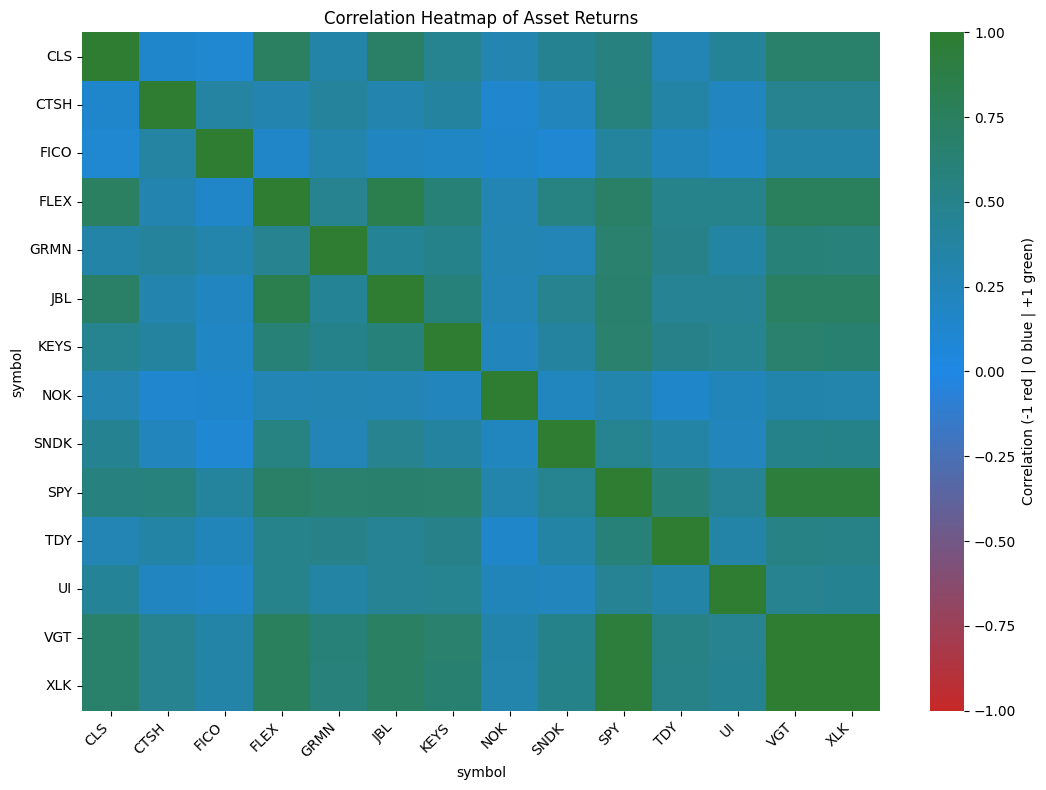

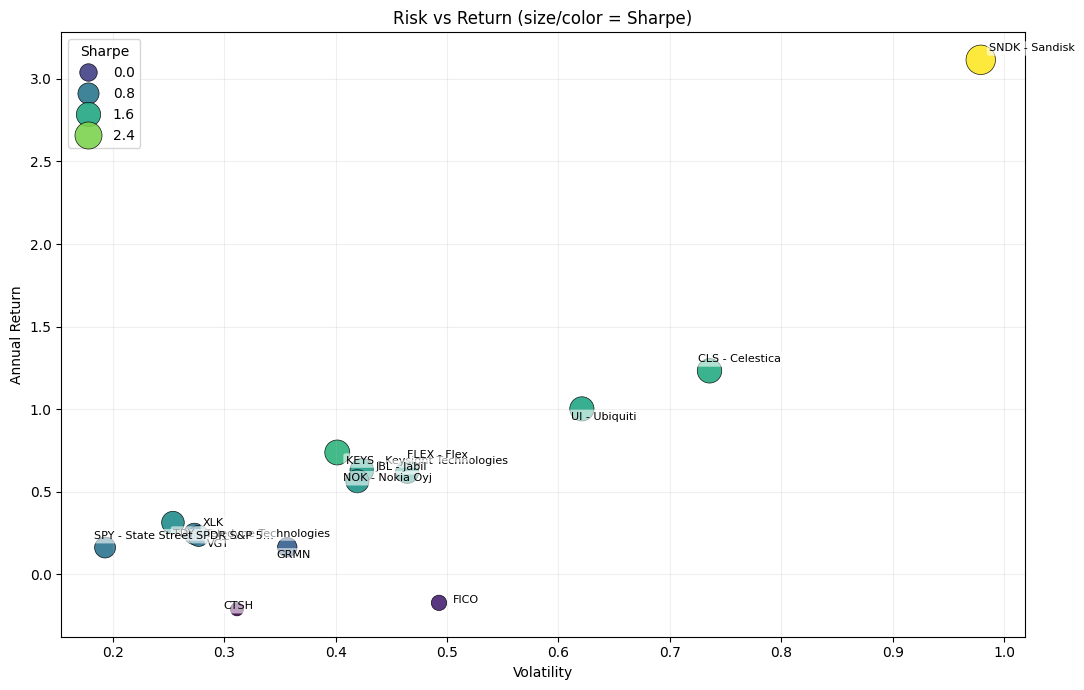

In [54]:
from matplotlib.colors import LinearSegmentedColormap

corr = returns.corr()
corr_offdiag = corr.where(~np.eye(len(corr), dtype=bool))
corr_min = np.nanmin(corr_offdiag.values)
corr_max = np.nanmax(corr_offdiag.values)
print(f"Off-diagonal correlation range in this sample: {corr_min:.3f} to {corr_max:.3f}")
if corr_min > 0:
    print("All pairwise correlations are positive in this period. This can happen when assets share sector/market direction.")

# Emotion-centered diverging map: negative=red, zero=blue, positive=green
emotion_corr_cmap = LinearSegmentedColormap.from_list(
    "emotion_corr",
    [
        (0.00, "#c62828"),  # -1 (red)
        (0.50, "#1e88e5"),  #  0 (blue)
        (1.00, "#2e7d32"),  # +1 (green)
    ],
)

plt.figure(figsize=(11, 8))
sns.heatmap(
    corr,
    annot=False,
    cmap=emotion_corr_cmap,
    center=0,
    vmin=-1,
    vmax=1,
    cbar_kws={"label": "Correlation (-1 red | 0 blue | +1 green)"},
)
plt.title("Correlation Heatmap of Asset Returns")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

rr = relative_table.reset_index().rename(columns={"index": "symbol"})

legend_map = {}
if "symbol_legend_df" in globals() and isinstance(symbol_legend_df, pd.DataFrame) and not symbol_legend_df.empty:
    legend_map = dict(zip(symbol_legend_df["Symbol"].astype(str), symbol_legend_df["Company"].astype(str)))

def short_company_name(name, max_len=24):
    if pd.isna(name) or str(name).strip() == "":
        return ""
    text = str(name).strip()
    for suffix in [", Inc.", " Inc.", " Incorporated", " Corporation", " Corp.", " Ltd.", " Limited", " plc", " ETF", " Trust"]:
        text = text.replace(suffix, "")
    text = " ".join(text.split())
    return text if len(text) <= max_len else text[: max_len - 1] + "…"

full_label_count = min(8, len(rr))
top_symbols = set(rr.nlargest(full_label_count, "Sharpe")["symbol"].astype(str).tolist())
priority_symbols = top_symbols.union({str(SYMBOL).upper(), str(BENCHMARK).upper()})

plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=rr,
    x="Volatility",
    y="Annual Return",
    size="Sharpe",
    hue="Sharpe",
    sizes=(90, 450),
    palette="viridis",
    legend="brief",
    edgecolor="black",
    linewidth=0.5,
    alpha=0.9,
 )

offsets = [(6, 6), (6, -8), (-8, 6), (-8, -8), (10, 0), (-10, 0), (0, 10), (0, -10)]
for i, row in rr.iterrows():
    symbol = str(row["symbol"]).upper()
    company = short_company_name(legend_map.get(symbol, ""))
    if symbol in priority_symbols and company:
        label = f"{symbol} - {company}"
    else:
        label = symbol

    dx, dy = offsets[i % len(offsets)]
    plt.annotate(
        label,
        (row["Volatility"], row["Annual Return"]),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6, ec="none"),
    )

plt.title("Risk vs Return (size/color = Sharpe)")
plt.xlabel("Volatility")
plt.ylabel("Annual Return")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Phase 7 — Decision, Execution, and Monitoring

This phase turns analysis into a repeatable decision rule.

**Financial reasoning:** explicit scoring and thresholds reduce emotional bias and hindsight rationalization. A clear framework makes it easier to explain decisions, review mistakes, and update views when new evidence arrives.

### Decision Scoring Template

This cell combines evidence from all prior phases into one explicit decision output.

**Financial reasoning:** investment decisions involve trade-offs across quality, growth, valuation, timing, and risk. A weighted score makes those trade-offs visible and consistent. If you later disagree with an outcome, you can audit the weights or phase scores instead of relying on vague intuition.

### Score Explanation Table (Plain Language)

Use this as a quick glossary for the score outputs in the next cell.

| Metric | What it means | How to read your value |
|---|---|---|
| `business_quality` | Durability of the company model (scale, competitive position, profitability quality). | Higher is better. Low values mean weaker moat or less durable economics. |
| `fundamentals` | Financial operating health (growth trend, margin quality, balance-sheet strength). | Higher is better. Low values suggest weaker business trajectory or balance stress. |
| `technicals` | Market timing quality from trend + momentum behavior. | Higher is better for entry timing. Low values suggest weaker setup right now. |
| `valuation` | Price attractiveness relative to earnings/cash flow/sales. | Higher is better (more attractive pricing). Lower can mean the stock is expensive. |
| `risk_fit` | Risk-adjusted suitability for portfolio use (drawdown, return quality, market sensitivity). | Higher is better. Low means rougher ride or weaker downside profile. |
| `relative_peer_score` | How the stock ranks versus peers/sector alternatives. | Higher is better. Low means better alternatives may exist in the same space. |

### Interpreting 0–5 score bands

| Score band | Label | Meaning |
|---|---|---|
| `4.20 - 5.00` | Strong | Clear strength in this area |
| `3.60 - 4.19` | Good | Generally favorable |
| `2.80 - 3.59` | Mixed | Balanced/uncertain; monitor |
| `0.00 - 2.79` | Weak | Potential concern or mismatch |

The next code cell combines these six dimensions using weights to produce the final decision label.

In [59]:
def _safe_float(value):
    try:
        num = float(value)
        return num if pd.notna(num) else np.nan
    except Exception:
        return np.nan

def _clamp(value, low=0.0, high=5.0):
    return max(low, min(high, value))

def _get_index_value(df, index_label, value_col="value"):
    if df is None or not isinstance(df, pd.DataFrame) or df.empty:
        return np.nan
    if value_col in df.columns and index_label in df.index:
        return _safe_float(df.loc[index_label, value_col])
    return np.nan

# -----------------------------
# 1) Business quality (0-5)
# -----------------------------
market_cap = _safe_float(phase1_summary["market_cap"].iloc[0]) if "phase1_summary" in globals() and not phase1_summary.empty else np.nan
peer_count = _safe_float(phase1_summary["peer_count"].iloc[0]) if "phase1_summary" in globals() and not phase1_summary.empty else np.nan
net_margin = _get_index_value(fundamental_kpi_df if "fundamental_kpi_df" in globals() else None, "Net Margin (last)")
roic = _get_index_value(fundamental_kpi_df if "fundamental_kpi_df" in globals() else None, "ROIC (last)")

size_score = 0.5
if pd.notna(market_cap):
    if market_cap >= 200e9:
        size_score = 2.0
    elif market_cap >= 50e9:
        size_score = 1.6
    elif market_cap >= 10e9:
        size_score = 1.2
    elif market_cap >= 2e9:
        size_score = 0.8

peer_score = 0.5
if pd.notna(peer_count):
    if peer_count >= 8:
        peer_score = 1.0
    elif peer_count >= 4:
        peer_score = 0.8
    elif peer_count >= 1:
        peer_score = 0.6

profitability_score = 1.0
if pd.notna(net_margin) and pd.notna(roic):
    nm = 1.0 if net_margin >= 0.15 else (0.8 if net_margin >= 0.08 else (0.5 if net_margin >= 0.03 else 0.2))
    rc = 1.0 if roic >= 0.12 else (0.8 if roic >= 0.08 else (0.5 if roic >= 0.04 else 0.2))
    profitability_score = nm + rc
elif pd.notna(net_margin):
    profitability_score = 1.0 if net_margin >= 0.12 else (0.7 if net_margin >= 0.05 else 0.3)
elif pd.notna(roic):
    profitability_score = 1.0 if roic >= 0.10 else (0.7 if roic >= 0.05 else 0.3)

business_quality = _clamp(size_score + peer_score + profitability_score)

# -----------------------------
# 2) Fundamentals (0-5)
# -----------------------------
fdf = fundamental_kpi_df if "fundamental_kpi_df" in globals() else pd.DataFrame()
rev_g = _get_index_value(fdf, "Revenue Growth (last)")
eps_g = _get_index_value(fdf, "EPS Growth (last)")
fcf_g = _get_index_value(fdf, "FCF Growth (last)")
op_margin = _get_index_value(fdf, "Operating Margin (last)")
de_ratio = _get_index_value(fdf, "Debt/Equity (last)")
cur_ratio = _get_index_value(fdf, "Current Ratio (last)")

growth_score = 0.0
for g in [rev_g, eps_g, fcf_g]:
    if pd.notna(g):
        growth_score += 0.7 if g >= 0.10 else (0.5 if g >= 0.03 else (0.3 if g >= 0 else 0.1))
    else:
        growth_score += 0.3
growth_score = min(growth_score, 2.1)

quality_score = 0.5
if pd.notna(op_margin):
    quality_score = 1.4 if op_margin >= 0.15 else (1.0 if op_margin >= 0.08 else (0.6 if op_margin >= 0.03 else 0.2))

balance_score = 0.5
if pd.notna(de_ratio) and pd.notna(cur_ratio):
    de_part = 0.8 if de_ratio <= 0.8 else (0.6 if de_ratio <= 1.5 else (0.3 if de_ratio <= 2.5 else 0.1))
    cr_part = 0.7 if cur_ratio >= 1.5 else (0.5 if cur_ratio >= 1.0 else 0.2)
    balance_score = de_part + cr_part
elif pd.notna(de_ratio):
    balance_score = 0.8 if de_ratio <= 1.2 else (0.5 if de_ratio <= 2.0 else 0.2)
elif pd.notna(cur_ratio):
    balance_score = 0.7 if cur_ratio >= 1.3 else (0.5 if cur_ratio >= 1.0 else 0.2)

fundamentals = _clamp(growth_score + quality_score + balance_score)

# -----------------------------
# 3) Technicals (0-5)
# -----------------------------
tdf = technical_kpis if "technical_kpis" in globals() else pd.DataFrame()
rsi = _safe_float(tdf["RSI(14)"].iloc[0]) if isinstance(tdf, pd.DataFrame) and "RSI(14)" in tdf.columns and not tdf.empty else np.nan
adx = _safe_float(tdf["ADX(14)"].iloc[0]) if isinstance(tdf, pd.DataFrame) and "ADX(14)" in tdf.columns and not tdf.empty else np.nan
obv = _safe_float(tdf["OBV"].iloc[0]) if isinstance(tdf, pd.DataFrame) and "OBV" in tdf.columns and not tdf.empty else np.nan

rsi_score = 1.0
if pd.notna(rsi):
    rsi_score = 2.0 if 45 <= rsi <= 65 else (1.5 if 35 <= rsi <= 75 else 0.8)

adx_score = 1.0
if pd.notna(adx):
    adx_score = 1.5 if 20 <= adx <= 45 else (1.1 if 15 <= adx <= 60 else 0.7)

obv_score = 0.8
if pd.notna(obv):
    obv_score = 1.2 if obv > 0 else 0.7

technicals = _clamp(rsi_score + adx_score + obv_score)

# -----------------------------
# 4) Valuation (0-5)
# -----------------------------
vdf = valuation_df if "valuation_df" in globals() else pd.DataFrame()
pe = _get_index_value(vdf, "P/E (last)")
ey = _get_index_value(vdf, "Earnings Yield (last)")
ev_ebitda = _get_index_value(vdf, "EV/EBITDA (last)")

if pd.notna(pe):
    pe_score = 2.0 if pe <= 15 else (1.6 if pe <= 22 else (1.1 if pe <= 30 else (0.6 if pe <= 40 else 0.2)))
else:
    pe_score = 0.9

if pd.notna(ey):
    ey_score = 1.5 if ey >= 0.07 else (1.1 if ey >= 0.045 else (0.7 if ey >= 0.025 else 0.3))
else:
    ey_score = 0.7

if pd.notna(ev_ebitda):
    ev_score = 1.5 if ev_ebitda <= 10 else (1.1 if ev_ebitda <= 16 else (0.7 if ev_ebitda <= 24 else 0.3))
else:
    ev_score = 0.7

valuation = _clamp(pe_score + ey_score + ev_score)

# -----------------------------
# 5) Risk fit (0-5)
# -----------------------------
rdf = risk_kpi_df if "risk_kpi_df" in globals() else pd.DataFrame()
sharpe_v = _get_index_value(rdf, "Sharpe")
sortino_v = _get_index_value(rdf, "Sortino")
beta_v = _get_index_value(rdf, "Beta")
maxdd_v = _get_index_value(rdf, "Max Drawdown")

if pd.notna(sharpe_v):
    sharpe_score = 2.0 if sharpe_v >= 1.5 else (1.6 if sharpe_v >= 1.0 else (1.1 if sharpe_v >= 0.5 else (0.6 if sharpe_v >= 0 else 0.2)))
else:
    sharpe_score = 0.8

if pd.notna(sortino_v):
    sortino_score = 1.5 if sortino_v >= 2.0 else (1.2 if sortino_v >= 1.2 else (0.8 if sortino_v >= 0.6 else 0.3))
else:
    sortino_score = 0.7

if pd.notna(maxdd_v):
    mdd_score = 1.0 if maxdd_v >= -0.15 else (0.7 if maxdd_v >= -0.30 else (0.4 if maxdd_v >= -0.45 else 0.2))
else:
    mdd_score = 0.5

if pd.notna(beta_v):
    beta_score = 0.5 if 0.8 <= beta_v <= 1.2 else (0.35 if 0.6 <= beta_v <= 1.5 else 0.2)
else:
    beta_score = 0.3

risk_fit = _clamp(sharpe_score + sortino_score + mdd_score + beta_score)

# -----------------------------
# 6) Relative peer score (0-5)
# -----------------------------
if "relative_table" in globals() and isinstance(relative_table, pd.DataFrame) and not relative_table.empty and SYMBOL in relative_table.index:
    rt = relative_table.copy()
    sharpe_rank = rt["Sharpe"].rank(ascending=False, method="average")
    ret_rank = rt["Annual Return"].rank(ascending=False, method="average")
    n = len(rt)
    if n > 1:
        sharpe_pct = 1 - ((sharpe_rank.loc[SYMBOL] - 1) / (n - 1))
        ret_pct = 1 - ((ret_rank.loc[SYMBOL] - 1) / (n - 1))
        relative_peer_score = _clamp(5 * (0.7 * sharpe_pct + 0.3 * ret_pct))
    else:
        relative_peer_score = 2.5
else:
    relative_peer_score = np.nan

scores = {
    "business_quality": round(business_quality, 2) if pd.notna(business_quality) else np.nan,
    "fundamentals": round(fundamentals, 2) if pd.notna(fundamentals) else np.nan,
    "technicals": round(technicals, 2) if pd.notna(technicals) else np.nan,
    "valuation": round(valuation, 2) if pd.notna(valuation) else np.nan,
    "risk_fit": round(risk_fit, 2) if pd.notna(risk_fit) else np.nan,
    "relative_peer_score": round(relative_peer_score, 2) if pd.notna(relative_peer_score) else np.nan,
}

weights = {
    "business_quality": 0.08,
    "fundamentals": 0.25,
    "technicals": 0.15,
    "valuation": 0.20,
    "risk_fit": 0.12,
    "relative_peer_score": 0.20,
}

if all(pd.notna(v) for v in scores.values()):
    total_score = sum(scores[k] * weights[k] for k in scores)
else:
    total_score = np.nan

def decision_label(score):
    if pd.isna(score):
        return "Pending"
    if score >= 4.2:
        return "Strong Buy"
    if score >= 3.6:
        return "Buy"
    if score >= 2.8:
        return "Hold/Watch"
    return "Avoid/Sell"

decision_df = pd.DataFrame([
    {
        "symbol": SYMBOL,
        "total_score": round(total_score, 2) if pd.notna(total_score) else np.nan,
        "decision": decision_label(total_score),
        "generated_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    }
])

scores_df = pd.DataFrame(scores, index=["score"]).T.rename(columns={"score": "value"})

def _score_band(value):
    if pd.isna(value):
        return "Unknown"
    if value >= 4.2:
        return "Strong"
    if value >= 3.6:
        return "Good"
    if value >= 2.8:
        return "Mixed"
    return "Weak"

def _explain_metric(metric, value):
    band = _score_band(value)
    metric_text = {
        "business_quality": "Business quality measures company durability: scale, competitive standing, and profitability strength.",
        "fundamentals": "Fundamentals measure operating health: growth trend, profit efficiency, and balance-sheet resilience.",
        "technicals": "Technicals measure timing context: momentum and trend quality rather than long-term business value.",
        "valuation": "Valuation measures price attractiveness: whether current price is expensive or reasonable versus earnings/cash flow.",
        "risk_fit": "Risk fit measures portfolio behavior: return quality relative to volatility and downside drawdowns.",
        "relative_peer_score": "Relative peer score measures rank versus alternatives: how this stock performs against peers and sector proxies.",
    }.get(metric, "")
    band_text = {
        "Strong": "Current reading is strong.",
        "Good": "Current reading is good.",
        "Mixed": "Current reading is mixed.",
        "Weak": "Current reading is weak.",
        "Unknown": "Current reading is unavailable.",
    }[band]
    return f"{metric_text} {band_text}"

legend_df = pd.DataFrame([
    {
        "Metric": "business_quality",
        "What It Means": "Durability and quality of the business model.",
        "How To Read": "Higher is better; weak means fragile economics.",
        "Your Value": scores.get("business_quality", np.nan),
        "Interpretation": _explain_metric("business_quality", scores.get("business_quality", np.nan)),
    },
    {
        "Metric": "fundamentals",
        "What It Means": "Growth + margins + balance sheet strength.",
        "How To Read": "Higher is better; weak suggests poor financial trajectory.",
        "Your Value": scores.get("fundamentals", np.nan),
        "Interpretation": _explain_metric("fundamentals", scores.get("fundamentals", np.nan)),
    },
    {
        "Metric": "technicals",
        "What It Means": "Entry timing quality from trend/momentum behavior.",
        "How To Read": "Higher is better for timing; lower implies weaker setup.",
        "Your Value": scores.get("technicals", np.nan),
        "Interpretation": _explain_metric("technicals", scores.get("technicals", np.nan)),
    },
    {
        "Metric": "valuation",
        "What It Means": "How cheap/expensive the stock is versus fundamentals.",
        "How To Read": "Higher is better (more attractive pricing).",
        "Your Value": scores.get("valuation", np.nan),
        "Interpretation": _explain_metric("valuation", scores.get("valuation", np.nan)),
    },
    {
        "Metric": "risk_fit",
        "What It Means": "How suitable the stock is for risk-adjusted portfolio fit.",
        "How To Read": "Higher is better; weak means downside behavior is concerning.",
        "Your Value": scores.get("risk_fit", np.nan),
        "Interpretation": _explain_metric("risk_fit", scores.get("risk_fit", np.nan)),
    },
    {
        "Metric": "relative_peer_score",
        "What It Means": "Ranking against peers and sector alternatives.",
        "How To Read": "Higher is better; weak means better alternatives likely exist.",
        "Your Value": scores.get("relative_peer_score", np.nan),
        "Interpretation": _explain_metric("relative_peer_score", scores.get("relative_peer_score", np.nan)),
    },
])

display(scores_df)
display(decision_df)
display(legend_df)

if pd.notna(total_score):
    metric_display = {
        "business_quality": "Business Quality",
        "fundamentals": "Fundamentals",
        "technicals": "Technicals",
        "valuation": "Valuation",
        "risk_fit": "Risk Fit",
        "relative_peer_score": "Peer Relative",
    }

    top_strengths = sorted(
        [(k, v) for k, v in scores.items() if pd.notna(v)],
        key=lambda item: item[1],
        reverse=True,
    )[:2]

    top_weaknesses = sorted(
        [(k, v) for k, v in scores.items() if pd.notna(v)],
        key=lambda item: item[1],
    )[:2]

    strength_text = ", ".join([f"{metric_display[k]} ({v:.2f}/5, {_score_band(v)})" for k, v in top_strengths])
    weakness_text = ", ".join([f"{metric_display[k]} ({v:.2f}/5, {_score_band(v)})" for k, v in top_weaknesses])

    overall_band = _score_band(total_score)
    action = decision_label(total_score)

    print("=== STOCK BRIEFING SUMMARY ===")
    print(
        f"{SYMBOL}: Overall composite score is {total_score:.2f}/5.00, which falls in the '{overall_band}' band and maps to recommendation '{action}'."
    )
    print(
        "Decision scale used: 4.20-5.00 Strong Buy | 3.60-4.19 Buy | 2.80-3.59 Hold/Watch | 0.00-2.79 Avoid/Sell."
    )
    print(f"Key strengths: {strength_text}.")
    print(f"Key watch-items: {weakness_text}.")
    print(
        "Interpretation: this recommendation is evidence-weighted across business durability, financial trajectory, timing, valuation, risk behavior, and peer-relative competitiveness."
    )

,value
business_quality,2.9
fundamentals,4.0
technicals,2.7
valuation,1.6
risk_fit,4.1
relative_peer_score,4.35


,symbol,total_score,decision,generated_at
0,CLS,3.32,Hold/Watch,2026-02-28 18:16:57


,Metric,What It Means,How To Read,Your Value,Interpretation
0,business_quality,Durability and quality of the business model.,Higher is better; weak means fragile economics.,2.9,Business quality measures company durability: ...
1,fundamentals,Growth + margins + balance sheet strength.,Higher is better; weak suggests poor financial...,4.0,Fundamentals measure operating health: growth ...
2,technicals,Entry timing quality from trend/momentum behav...,Higher is better for timing; lower implies wea...,2.7,Technicals measure timing context: momentum an...
3,valuation,How cheap/expensive the stock is versus fundam...,Higher is better (more attractive pricing).,1.6,Valuation measures price attractiveness: wheth...
4,risk_fit,How suitable the stock is for risk-adjusted po...,Higher is better; weak means downside behavior...,4.1,Risk fit measures portfolio behavior: return q...
5,relative_peer_score,Ranking against peers and sector alternatives.,Higher is better; weak means better alternativ...,4.35,Relative peer score measures rank versus alter...


=== STOCK BRIEFING SUMMARY ===
CLS: Overall composite score is 3.32/5.00, which falls in the 'Mixed' band and maps to recommendation 'Hold/Watch'.
Decision scale used: 4.20-5.00 Strong Buy | 3.60-4.19 Buy | 2.80-3.59 Hold/Watch | 0.00-2.79 Avoid/Sell.
Key strengths: Peer Relative (4.35/5, Strong), Risk Fit (4.10/5, Good).
Key watch-items: Valuation (1.60/5, Weak), Technicals (2.70/5, Weak).
Interpretation: this recommendation is evidence-weighted across business durability, financial trajectory, timing, valuation, risk behavior, and peer-relative competitiveness.


## Analyst Notes

Use this section to record thesis quality, not code notes.

- Write the **bull case** (what must go right).
- Write the **bear case** (what likely breaks the thesis).
- Define **invalidation triggers** (metrics/events that force re-evaluation).
- Re-run this notebook after earnings, guidance changes, or major sector/macro shifts.

**Financial reasoning:** documented assumptions make future performance reviews objective. This is how you improve decision quality over time.